# Task 3  Catenary wire identification

Here we will identify the catenary as the cluster with the largest combined x,y span, then report its bounding box and visualise it.

We know (visually) from Task 2, "Step 3 - Run DBSCAN and inspect clusters" that the catenary runs along the full length of the dataset (y-direction).
This gives it a larger combined x+y span than any other cluster, even if it contains fewer points than denser objects like trees or trackside installations.

## Step 1 - Reload data and re-run DBSCAN

Re-uses `get_ground_level` and the optimal eps values from Tasks 1 and 2 directly — no recalculation.
The `- 1` in `len(set(labels))` excludes the noise cluster (label = −1) from the count.
Expected output: 87 clusters for dataset1, 139 for dataset2.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Load datasets
pcd1 = np.load("dataset1.npy")
pcd2 = np.load("dataset2.npy")

# Ground filter (from Task 1)
def get_ground_level(pcd):
    counts, bin_edges = np.histogram(pcd[:, 2], bins=200)
    peak_idx = np.argmax(counts)
    return bin_edges[peak_idx + 1] + 0.5

pcd1_above = pcd1[pcd1[:, 2] > get_ground_level(pcd1)]
pcd2_above = pcd2[pcd2[:, 2] > get_ground_level(pcd2)]

# DBSCAN with optimal eps values from Task 2
eps1, eps2 = 0.958, 0.973
labels1 = DBSCAN(eps=eps1, min_samples=5).fit(pcd1_above).labels_
labels2 = DBSCAN(eps=eps2, min_samples=5).fit(pcd2_above).labels_

print(f"dataset1: {len(set(labels1)) - 1} clusters (excl. noise)")
print(f"dataset2: {len(set(labels2)) - 1} clusters (excl. noise)")

dataset1: 87 clusters (excl. noise)
dataset2: 139 clusters (excl. noise)


## Step 2 - Find the catenary cluster

Each DBSCAN cluster has a size in x and y. We measure x+y span for every cluster and pick the largest one. 
The catenary wire runs the full length of the track, so it will win that comparison.

In [14]:
def find_catenary(pcd, labels):
    """
    Returns the points of the cluster with the largest combined x,y span,
    excluding noise (label = -1).
    """
    unique_labels = [l for l in set(labels) if l != -1]

    best_label = None
    best_span = -1

    for label in unique_labels:
        pts = pcd[labels == label]
        x_span = pts[:, 0].max() - pts[:, 0].min()
        y_span = pts[:, 1].max() - pts[:, 1].min()
        if x_span + y_span > best_span:
            best_span = x_span + y_span
            best_label = label

    return pcd[labels == best_label]

cat1 = find_catenary(pcd1_above, labels1)
cat2 = find_catenary(pcd2_above, labels2)

print(f"dataset1 — catenary points: {len(cat1)}")
print(f"dataset2 — catenary points: {len(cat2)}")

dataset1 — catenary points: 12792
dataset2 — catenary points: 5301


Dataset1 contains 12 792 catenary points, dataset2 contains 5 301. 
The wire is smaller compared to bulkier clusters like trees, but its y-span dominates.

## Step 3 - "Bounding box"

Find the area defined with x and y 

In [15]:
def report_bbox(cat, name):
    print(f"{name} — catenary bounding box:")
    print(f"  min(x) = {cat[:, 0].min():.2f},  max(x) = {cat[:, 0].max():.2f}")
    print(f"  min(y) = {cat[:, 1].min():.2f},  max(y) = {cat[:, 1].max():.2f}")

report_bbox(cat1, "dataset1")
report_bbox(cat2, "dataset2")

dataset1 — catenary bounding box:
  min(x) = 26.50,  max(x) = 62.14
  min(y) = 80.02,  max(y) = 159.96
dataset2 — catenary bounding box:
  min(x) = 11.39,  max(x) = 37.01
  min(y) = 0.04,  max(y) = 79.98


Both datasets cover approximately 80 m in y, consistent with the expected track section length.
Dataset1 spans y = 80–160 m and dataset2 spans y = 0–80 m, confirming they cover the same 
corridor end to end. 

Note at this stage that we only take one cluster of each - while a visual lookat the renderings from above in Task 2 show that there seem to be other clusters ner or on it - this might be other types of cables.

## Step 4 - Visualize the catenary cluster

The identified cluster is plotted in x,y with colour representing height (z).
Points are coloured by z-value to verify that the wire sits at a consistent height along the track.

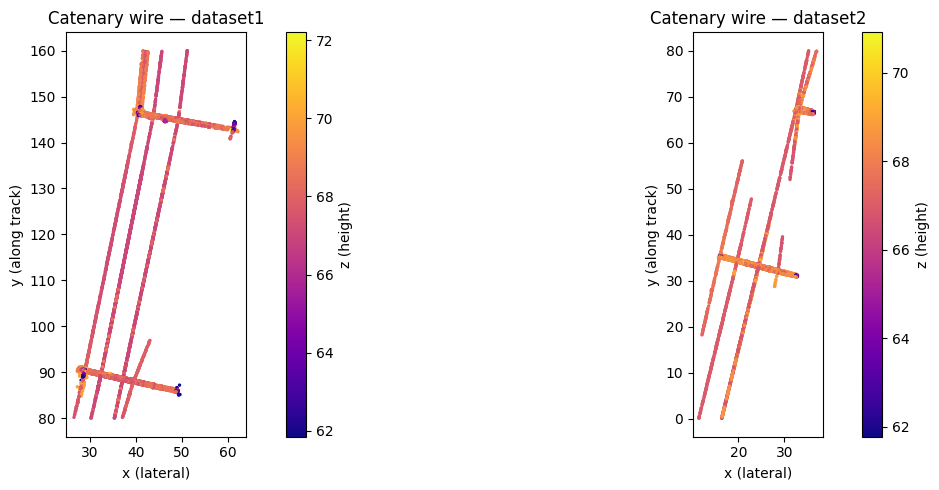

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cat, name in zip(axes, [cat1, cat2], ["dataset1", "dataset2"]):
    sc = ax.scatter(cat[:, 0], cat[:, 1], c=cat[:, 2],
                    cmap='plasma', s=2)
    plt.colorbar(sc, ax=ax, label='z (height)')
    ax.set_title(f"Catenary wire — {name}")
    ax.set_xlabel("x (lateral)")
    ax.set_ylabel("y (along track)")
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

For dataset 2 we can visually see by comparing it to the etrndered image in Task 2, that tha canopy has been split up in more than one cluster.
The method we use only picks the largest one, as required by the assignment.

Height (z) is consistent along the wire at around 66–68 m, with isolated darker points at the suspension structures.